<p style="color:#824AE8;font-family:Ubuntu Light;font-size:140%">DATA SCIENCE IN CHEMISTRY</p>

# Introduction to Cheminformatics with RDKit

In [1]:
pip install rdkit

Note: you may need to restart the kernel to use updated packages.


In [2]:
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from rdkit.Chem.Draw import IPythonConsole

In [3]:
IPythonConsole.ipython_useSVG = True
IPythonConsole.drawOptions.addAtomIndices = True
IPythonConsole.molSize = 400, 400

____________________________

## Creating Molecules with RDKit

In [4]:
methane = Chem.MolFromSmiles("C")

In [5]:
type(methane)

rdkit.Chem.rdchem.Mol

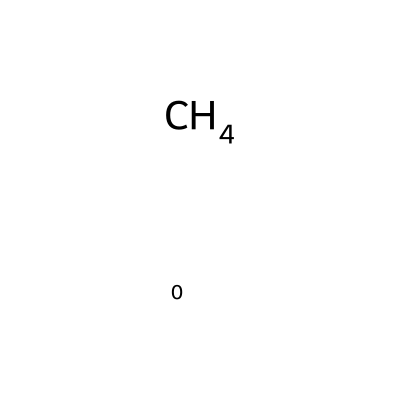

In [6]:
methane

In [7]:
import pubchempy as pcp
warfarin = pcp.get_compounds("warfarin", "name")[0]
smiles = warfarin.canonical_smiles

print(smiles)

CC(=O)CC(C1=CC=CC=C1)C2=C(C3=CC=CC=C3OC2=O)O


________________________________

## Generating 2D and 3D Structures

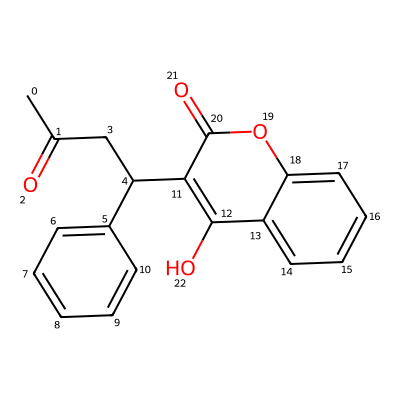

In [8]:
warfarin_mol = Chem.MolFromSmiles(smiles)
warfarin_mol

### 2D Geomteries

In [9]:
AllChem.Compute2DCoords(warfarin_mol)

0

In [10]:
print(Chem.MolToMolBlock(warfarin_mol))


     RDKit          2D

 23 25  0  0  0  0  0  0  0  0999 V2000
   -4.2622    3.1762    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -3.4645    1.9059    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -4.1657    0.5799    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
   -1.9655    1.9616    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.1678    0.6913    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.8690   -0.6347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -3.3680   -0.6904    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -4.0692   -2.0164    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -3.2715   -3.2867    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.7725   -3.2309    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.0713   -1.9049    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.3312    0.7471    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.1289   -0.5232    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.6279   -0.4675    0

In [11]:
warfarin_mol_h = Chem.AddHs(warfarin_mol)

In [13]:
print(Chem.MolToMolBlock(warfarin_mol_h), file = open("warfarin_mol_h_2d.mol", "w+"))

In [14]:
warfarin_mol_no_h = Chem.RemoveHs(warfarin_mol_h)
print(Chem.MolToMolBlock(warfarin_mol_no_h))


     RDKit          2D

 23 25  0  0  0  0  0  0  0  0999 V2000
   -4.2622    3.1762    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -3.4645    1.9059    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -4.1657    0.5799    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
   -1.9655    1.9616    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.1678    0.6913    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.8690   -0.6347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -3.3680   -0.6904    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -4.0692   -2.0164    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -3.2715   -3.2867    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.7725   -3.2309    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.0713   -1.9049    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.3312    0.7471    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.1289   -0.5232    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.6279   -0.4675    0

### 3D Geometries

In [15]:
AllChem.EmbedMolecule(warfarin_mol_h)

0

In [19]:
print(Chem.MolToMolBlock(warfarin_mol_h), file = open("warfarin_mol_h_3d.mol", "w+"))

In [17]:
warfarin_mol_h.SetProp("_Name", "Warfarin_3D")

______________________________________________

## Reading and Writing Molecules

### - Reading multiple molecules

In [20]:
sdfmols = Chem.SDMolSupplier("pubchem_molecules.sdf", removeHs = False)
mols = [mol for mol in sdfmols if mol is not None]
mols

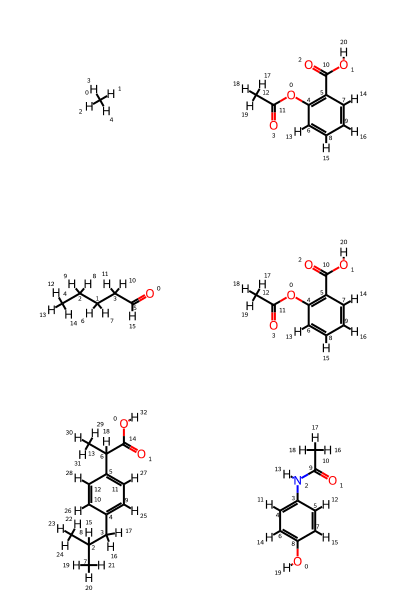

In [21]:
img = Draw.MolsToGridImage(mols[:6],
                          molsPerRow = 2,
                          subImgSize = (200, 200))

img

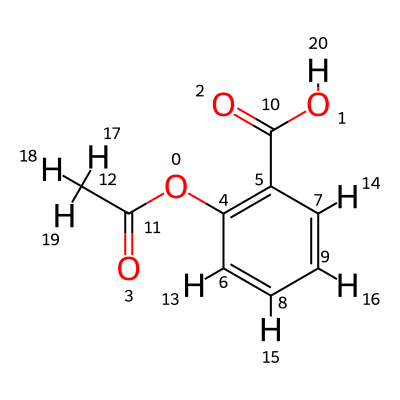

In [22]:
mols[1]

### - Reading MOL files

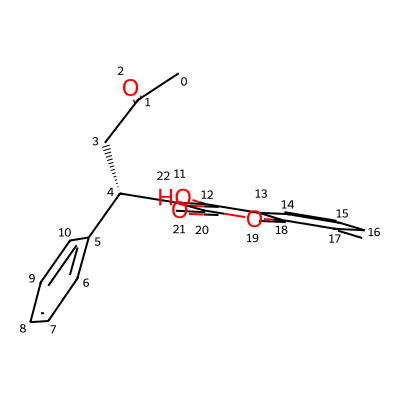

In [23]:
warf = Chem.MolFromMolFile("warfarin_mol_h_3d.mol")
warf

In [24]:
print(Chem.MolToMolBlock(warf))

Warfarin_3D
     RDKit          3D

 23 25  0  0  0  0  0  0  0  0999 V2000
    0.1257    3.4372   -0.0816 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.9185    2.7530    0.7403 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.1117    3.0746    1.9233 O   0  0  0  0  0  0  0  0  0  0  0  0
   -1.7717    1.6481    0.1596 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.3837    0.3465    0.8333 C   0  0  1  0  0  0  0  0  0  0  0  0
   -2.1857   -0.7826    0.3075 C   0  0  0  0  0  0  0  0  0  0  0  0
   -2.4799   -1.8395    1.1721 C   0  0  0  0  0  0  0  0  0  0  0  0
   -3.2246   -2.9282    0.7698 C   0  0  0  0  0  0  0  0  0  0  0  0
   -3.6855   -2.9588   -0.5296 C   0  0  0  0  0  0  0  0  0  0  0  0
   -3.4191   -1.9366   -1.4195 C   0  0  0  0  0  0  0  0  0  0  0  0
   -2.6679   -0.8624   -0.9734 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0671    0.1116    0.8115 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.8298    0.0707   -0.3351 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.1925   -

### - Writing molecules

In [25]:
mol_out = Chem.SDWriter("mol3.sdf")
mol_out.write(mols[4])
mol_out.close()

In [26]:
Chem.MolToMolFile(mols[1], "mol2.mol")

### - Writing and Reading xyz Files

In [27]:
warf_xyz = AllChem.MolToXYZBlock(warfarin_mol_h)
print(warf_xyz)

39
Warfarin_3D
C      0.125746    3.437153   -0.081648
C     -0.918493    2.753036    0.740330
O     -1.111718    3.074588    1.923265
C     -1.771672    1.648109    0.159578
C     -1.383677    0.346514    0.833297
C     -2.185725   -0.782591    0.307454
C     -2.479946   -1.839497    1.172086
C     -3.224581   -2.928250    0.769763
C     -3.685458   -2.958758   -0.529586
C     -3.419134   -1.936566   -1.419455
C     -2.667865   -0.862428   -0.973387
C      0.067134    0.111555    0.811481
C      0.829827    0.070673   -0.335071
C      2.192484   -0.151253   -0.318078
C      2.901026   -0.181175   -1.490654
C      4.270226   -0.408128   -1.411668
C      4.901571   -0.598052   -0.197822
C      4.162375   -0.563696    0.978144
C      2.795792   -0.336965    0.902622
O      2.074128   -0.298332    1.987454
C      0.772877   -0.088895    2.006930
O      0.152345   -0.066219    3.092277
O      0.238294    0.255069   -1.562512
H      0.168350    4.528595    0.059221
H     -0.095612    3.2089

In [28]:
Chem.MolToXYZFile(warfarin_mol_h, "warfarin_xyz.xyz")

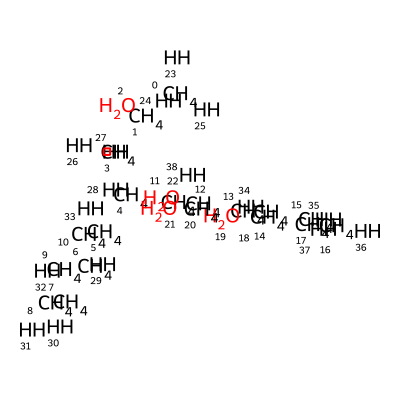

In [29]:
xyz_warf = Chem.MolFromXYZFile("warfarin_xyz.xyz")
xyz_warf

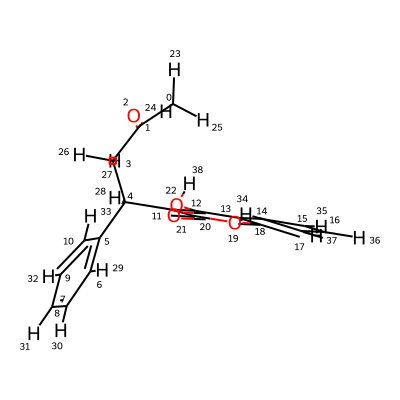

In [30]:
from rdkit.Chem import rdDetermineBonds
rdDetermineBonds.DetermineBonds(xyz_warf)
xyz_warf

_______________________________________________________________

## Properties of a Mol Object 

- GetProp(name)
- SetProp(name, value)
- GetPropNames()

In [32]:
for prop in mols[0].GetPropNames():
    print(f"{prop}: {mols[0].GetProp(prop)}")

PUBCHEM_COMPOUND_CID: 297
PUBCHEM_COMPOUND_CANONICALIZED: 1
PUBCHEM_CACTVS_COMPLEXITY: 0
PUBCHEM_CACTVS_HBOND_ACCEPTOR: 0
PUBCHEM_CACTVS_HBOND_DONOR: 0
PUBCHEM_CACTVS_ROTATABLE_BOND: 0
PUBCHEM_CACTVS_SUBSKEYS: AAADcYAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAEAAAAAAAAAAAAAACAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA==
PUBCHEM_IUPAC_OPENEYE_NAME: methane
PUBCHEM_IUPAC_CAS_NAME: methane
PUBCHEM_IUPAC_NAME_MARKUP: methane
PUBCHEM_IUPAC_NAME: methane
PUBCHEM_IUPAC_SYSTEMATIC_NAME: methane
PUBCHEM_IUPAC_TRADITIONAL_NAME: methane
PUBCHEM_IUPAC_INCHI: InChI=1S/CH4/h1H4
PUBCHEM_IUPAC_INCHIKEY: VNWKTOKETHGBQD-UHFFFAOYSA-N
PUBCHEM_XLOGP3_AA: 0.6
PUBCHEM_EXACT_MASS: 16.0313001276
PUBCHEM_MOLECULAR_FORMULA: CH4
PUBCHEM_MOLECULAR_WEIGHT: 16.043
PUBCHEM_OPENEYE_CAN_SMILES: C
PUBCHEM_OPENEYE_ISO_SMILES: C
PUBCHEM_CACTVS_TPSA: 0
PUBCHEM_MONOISOTOPIC_WEIGHT: 16.0313001276
PUBCHEM_TOTAL_CHARGE: 0
PUBCHEM_HEAVY_ATOM_COUNT: 1
PUBCHEM_ATOM_DEF_STEREO_COUNT: 0


________________________________________________

## Components of a Mol object

### - Atom Object

- Mol.GetAtoms()
- Mol.GetAtomWithIdx(idx)

| Atom Information                                            | Method      |
| ----------------------------------------------------------- | ----------- |
| index                                               | atom.GetIdx()    |
| atomic number                                                  | atom.GetAtomicNum()        |
| Element symbol | atom.GetSymbol()   |
| mass  | atom.GetMass() |
| Hybridization                  | atom.GetHybridization()    |
| Aromatic or not?                 | atom.GetIsAromatic()    |

In [33]:
ethanol = "CCO"
mol = Chem.MolFromSmiles(ethanol)
for atom in mol.GetAtoms():
    print(f"Index: {atom.GetIdx()}")
    print(f"Atomic Number: {atom.GetAtomicNum()}")
    print(f"Symbol: {atom.GetSymbol()}")
    print(f"Hybridization: {atom.GetHybridization()}")
    print("_" * 40)

Index: 0
Atomic Number: 6
Symbol: C
Hybridization: SP3
________________________________________
Index: 1
Atomic Number: 6
Symbol: C
Hybridization: SP3
________________________________________
Index: 2
Atomic Number: 8
Symbol: O
Hybridization: SP3
________________________________________


In [34]:
atom = mol.GetAtomWithIdx(0)
print("Atomic Symbol:", atom.GetSymbol())
print("Atomic Number:", atom.GetAtomicNum())

Atomic Symbol: C
Atomic Number: 6


In [35]:
for mol in mols[:4]:
    print(mol.GetProp("PUBCHEM_IUPAC_NAME"))
    for atom in mol.GetAtoms():
        if atom.GetSymbol() == "C" and str(atom.GetHybridization()) == "SP3":
            print(f"Index for sp3 Carbon: {atom.GetIdx()}")
            
    print("_" * 40)

methane
Index for sp3 Carbon: 0
________________________________________
2-acetyloxybenzoic acid
Index for sp3 Carbon: 12
________________________________________
pentanal
Index for sp3 Carbon: 1
Index for sp3 Carbon: 2
Index for sp3 Carbon: 3
Index for sp3 Carbon: 4
________________________________________
2-acetyloxybenzoic acid
Index for sp3 Carbon: 12
________________________________________


### - Bond object

- Mol.GetBonds()
- Mol.GetBondWithIdx(idx)
- Mol.GetBondBetweenAtoms(atom_idx1, atom_idx2)

| Bond Information                                            | Method      |
| ----------------------------------------------------------- | ----------- |
| index                                               | bond.GetIdx()    |
| Type of bond                                                  |  bond.GetBondType()        |
| Aromatic bonding or not | bond.GetIsAromatic()   |
| Intra-ring join or not  | bond.IsInRing() |
| Get the starting atom                  |  bond.GetBeginAtom()    |
| Get the starting atom by Index                  |  bond.GetBeginAtomIdx()    |
| Get the endpoint atom                 |  bond.GetEndAtom()    |
| Get the endpoint atom by Index                |  bond.GetEndAtomIdx()    |


In [36]:
for mol in mols[:2]:
    print(mol.GetProp("PUBCHEM_IUPAC_NAME"))
    
    for bond in mol.GetBonds():
        if bond.GetIsAromatic():
            atom_a, atom_b = bond.GetBeginAtom(), bond.GetEndAtom()
            print(f"Bond between {atom_a.GetSymbol()}{atom_a.GetIdx()}-{atom_b.GetSymbol()}{atom_b.GetIdx()}")
            
    print("_" * 40)

methane
________________________________________
2-acetyloxybenzoic acid
Bond between C4-C5
Bond between C4-C6
Bond between C5-C7
Bond between C6-C8
Bond between C7-C9
Bond between C8-C9
________________________________________


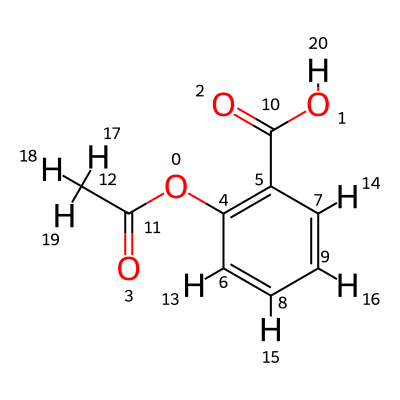

In [37]:
mols[1]

______________________________________________

## Editing Atoms with RDKit

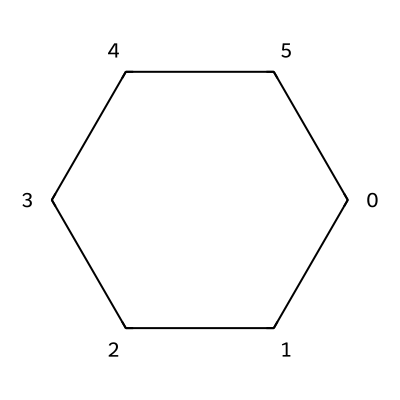

In [39]:
cyclohexane = Chem.MolFromSmiles("C1CCCCC1")
cyclohexane

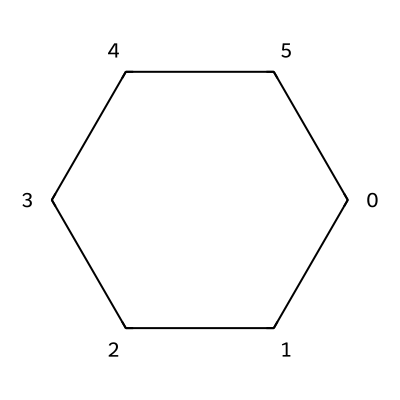

In [40]:
oxane = Chem.RWMol(cyclohexane)
oxane

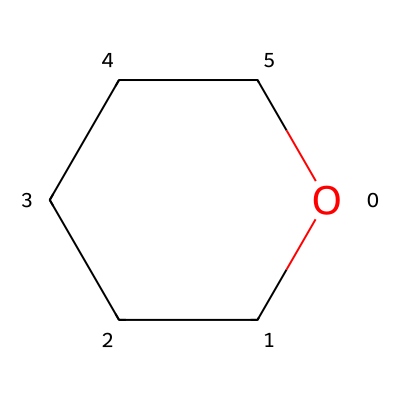

In [41]:
atom = oxane.GetAtomWithIdx(0)
atom.SetAtomicNum(8)
oxane

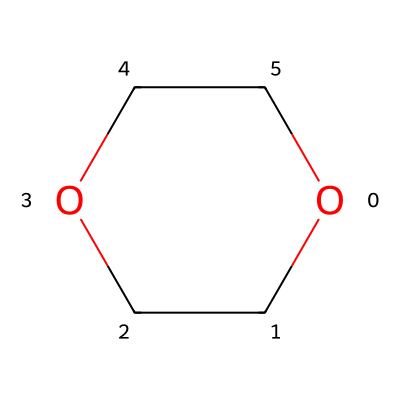

In [42]:
dioxane = Chem.RWMol(oxane)
atom = dioxane.GetAtomWithIdx(3)
atom.SetAtomicNum(8)
dioxane

_______________________________________________________

## Combining Two Molecules

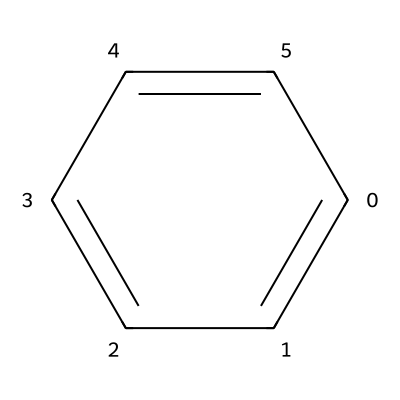

In [43]:
benzene = Chem.MolFromSmiles("c1ccccc1")
benzene

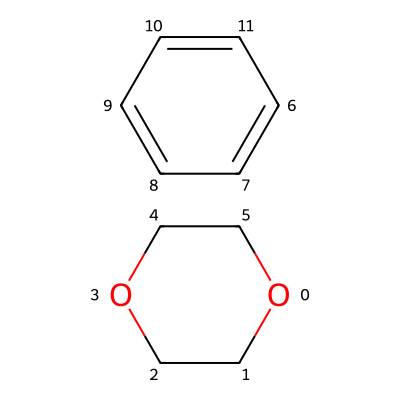

In [44]:
combine_mol = Chem.CombineMols(dioxane, benzene)
combine_mol

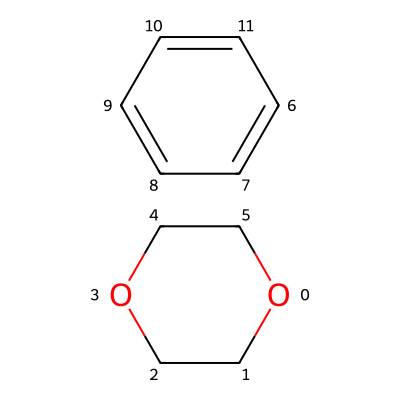

In [45]:
edit_mol = Chem.RWMol(combine_mol)
edit_mol

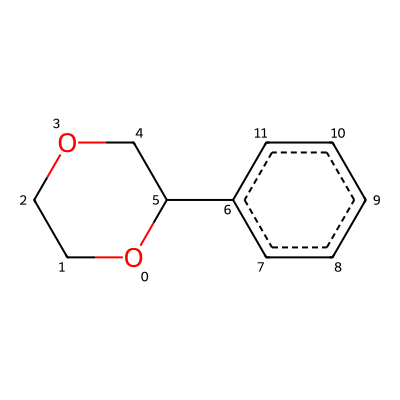

In [46]:
edit_mol.AddBond(5, 6, order = Chem.rdchem.BondType.SINGLE)
edit_mol

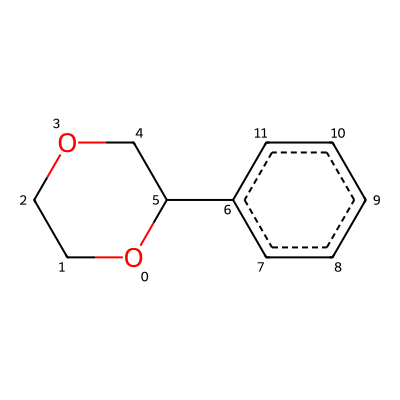

In [47]:
phenyldioxane = Chem.RWMol(edit_mol)
phenyldioxane

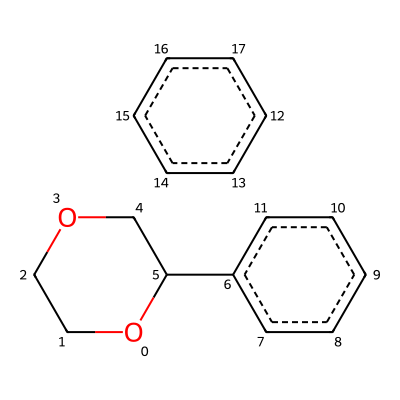

In [48]:
combine_mol2 = Chem.CombineMols(phenyldioxane, benzene)
edit_mol2 = Chem.RWMol(combine_mol2)
edit_mol2

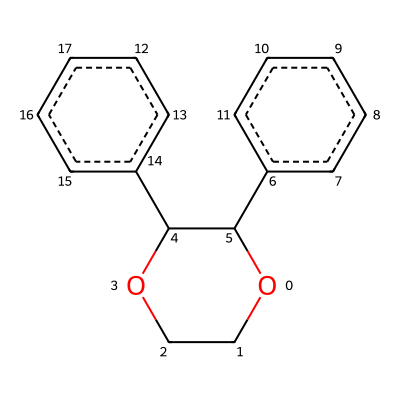

In [49]:
edit_mol2.AddBond(4, 14, order = Chem.rdchem.BondType.SINGLE)
edit_mol2

________________________________________________

## Molecular Sanitization

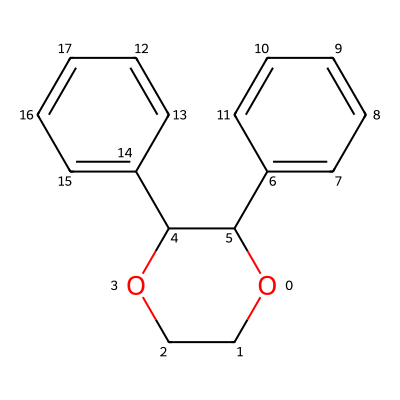

In [50]:
Chem.SanitizeMol(edit_mol2)
edit_mol2

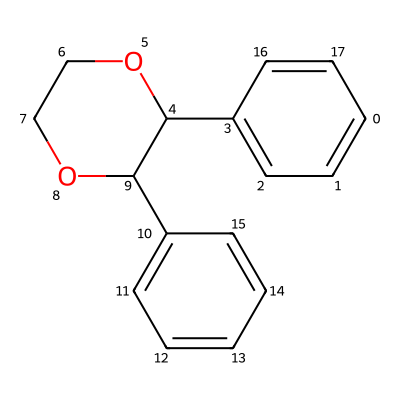

In [51]:
diphenyldioxane = Chem.MolToSmiles(edit_mol2)
Chem.MolFromSmiles(diphenyldioxane)

_________________________________________________

## Drawing Molecules

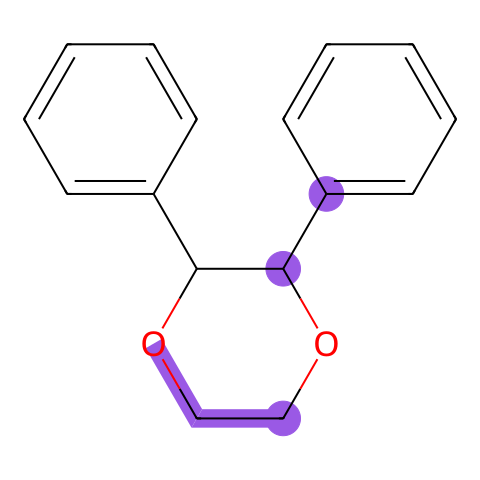

In [53]:
Draw.MolToImage(edit_mol2,
               size = (480, 480),
               kekulize = True,
               highlightAtoms = [1, 5, 6],
               highlightBonds = [1, 2],
               highlightColor = (154/255, 89/255, 229/255))